In [1]:
# import statements
import polars as pl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import norm
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.model_selection import cross_val_score
import scipy
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings

warnings.filterwarnings('ignore')

## Helper Functions 

In [3]:
# helper function:
def read_cme_csv(file_path: str,
                 float_dtype=pl.Float32,
                 str_cols=("icmecat_id", "sc_insitu"),
                 datetime_cols=("icme_start_time", "mo_start_time", "mo_end_time"),
                 infer_schema_length: int = 10000) -> pl.DataFrame:
    # get column names - read only the header without schema inference to avoid
    # parsing errors (some files contain floats that would otherwise be
    # mis-inferred as integers). Setting ``infer_schema_length=0`` prevents
    # Polars from scanning data when reading the header.
    header = pl.read_csv(file_path, n_rows=0, infer_schema_length=0, ignore_errors=True)
    cols = header.columns

    # build schema: two strings, three datetimes, rest floats
    schema_overrides = {}
    for c in cols:
        if c in str_cols:
            schema_overrides[c] = pl.Utf8
        elif c in datetime_cols:
            schema_overrides[c] = pl.Datetime
        else:
            schema_overrides[c] = float_dtype

    try:
        # prefer enforcing schema during parse
        return pl.read_csv(file_path, schema_overrides=schema_overrides, infer_schema_length=infer_schema_length)
    except Exception:
        # fallback: permissive read then cast explicitly
        df = pl.read_csv(file_path, infer_schema_length=0, ignore_errors=True)
        cast_exprs = []
        for c in df.columns:
            if c in str_cols:
                cast_exprs.append(pl.col(c).cast(pl.Utf8).alias(c))
            elif c in datetime_cols:
                cast_exprs.append(pl.col(c).str.strptime(pl.Datetime, fmt=None, strict=False).alias(c))
            else:
                cast_exprs.append(pl.col(c).cast(float_dtype).alias(c))
        return df.with_columns(cast_exprs)

# make the figure for bz, bt, sheath duration, and mo duration statistics
def plot_cme_statistics(cme_data: pl.DataFrame):
    """
    Plot bt_target, bz_target, sheath duration (hours), and MO duration (hours).
    Legends contain max, min, mean, std (no vertical lines).
    Returns (fig, axs).
    """

    # Convert durations (ns → hours)
    sheath_duration_hours = cme_data.select(
        (
            (pl.col('mo_start_time') - pl.col('icme_start_time'))
            .dt.cast_time_unit('ns')
            .cast(pl.Int64) / 3_600_000_000_000
        ).alias('sheath_hours')
    )['sheath_hours']

    mo_duration_hours = cme_data.select(
        (
            (pl.col('mo_end_time') - pl.col('mo_start_time'))
            .dt.cast_time_unit('ns')
            .cast(pl.Int64) / 3_600_000_000_000
        ).alias('mo_hours')
    )['mo_hours']

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # Small helper to format stats text
    def make_stats_legend(ax, data):
        stats_text = (
            f"Mean: {data.mean():.2f}\n"
            f"Std: {data.std():.2f}\n"
            f"Min: {data.min():.2f}\n"
            f"Max: {data.max():.2f}"
        )
        # Empty plot handle just for the legend text
        ax.legend([plt.Line2D([], [], color='none')], [stats_text], frameon=True, fontsize=12)

    # --- (1) bt_target ---
    bt = cme_data['bt_target'].to_numpy()
    axs[0, 0].hist(bt, bins=35, density=True, alpha=0.5, color='goldenrod')
    mu, sigma = norm.fit(bt)
    x = np.linspace(bt.min(), bt.max(), 500)
    axs[0, 0].plot(x, norm.pdf(x, mu, sigma), linewidth=2, color='goldenrod')
    axs[0, 0].set_title('$B_{tot}$', fontsize=18)
    axs[0, 0].set_xlabel('$B_{tot}$ (nT)', fontsize=14)
    axs[0, 0].set_ylabel('Frequency', fontsize=14)
    make_stats_legend(axs[0, 0], bt)

    # --- (2) bz_target ---
    bz = cme_data['bz_target'].to_numpy()
    axs[0, 1].hist(bz, bins=30, density = True, alpha=0.5, color='salmon')
    mu, sigma = norm.fit(bz)
    x = np.linspace(bz.min(), bz.max(), 500)
    axs[0, 1].plot(x, norm.pdf(x, mu, sigma), linewidth=2, color='salmon')
    axs[0, 1].set_title('$B_{z}$', fontsize=18)
    axs[0, 1].set_xlabel('$B_{z}$ (nT)', fontsize=14)
    axs[0, 1].set_ylabel('Frequency', fontsize=14)
    make_stats_legend(axs[0, 1], bz)

    # --- (3) sheath duration ---
    sh = sheath_duration_hours.to_numpy()
    axs[1, 0].hist(sh, bins=15, density = True, alpha = 0.5, color='purple')
    mu, sigma = norm.fit(sh)
    x = np.linspace(sh.min(), sh.max(), 500)
    axs[1, 0].plot(x, norm.pdf(x, mu, sigma), linewidth=2, color='purple')
    axs[1, 0].set_title('Sheath Duration', fontsize=18)
    axs[1, 0].set_xlabel('Sheath Duration (hours)', fontsize=14)
    axs[1, 0].set_ylabel('Frequency', fontsize=14)
    make_stats_legend(axs[1, 0], sh)

    # --- (4) MO duration ---
    mo = mo_duration_hours.to_numpy()
    axs[1, 1].hist(mo, bins=25, density = True, alpha = 0.5, color='green')
    mu, sigma = norm.fit(mo)
    x = np.linspace(mo.min(), mo.max(), 500)
    axs[1, 1].plot(x, norm.pdf(x, mu, sigma), linewidth=2, color='green')
    axs[1, 1].set_title('MO Duration', fontsize=18)
    axs[1, 1].set_xlabel('MO Duration (hours)', fontsize=14)
    axs[1, 1].set_ylabel('Frequency', fontsize=14)
    make_stats_legend(axs[1, 1], mo)

    fig.tight_layout()
    return fig, axs

## Data Visualization

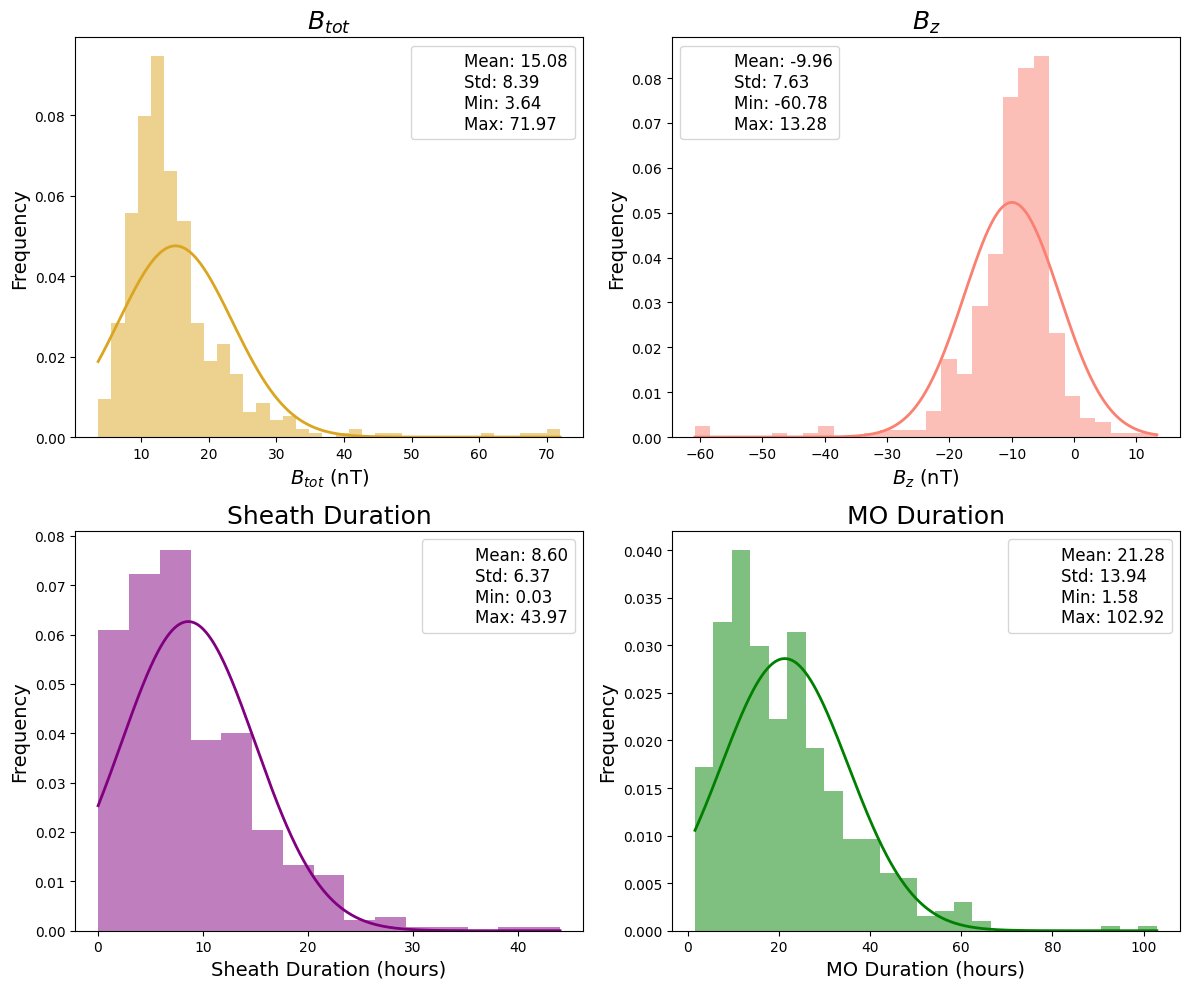

In [5]:
file = "CME_features_sheath_and_MO_4.csv"
file_path = "../../Data/feature_space/" + file
cme_data = read_cme_csv(file_path)

# make features and targets:
# make a fearure space dataframe. it should include all the columns that are f32 except for bt_target and bz_target
feature_cols = [col for col in cme_data.columns if cme_data[col].dtype == pl.Float32 and col not in ['bt_target', 'bz_target']]
# X = scale_features(cme_data.select(feature_cols))

X = cme_data.select(feature_cols)

# make the target feature dataframe that are bt_target and bz_target
y = cme_data.select(['bt_target', 'bz_target'])

# alright, lets make some figures and do some visualization!
# plot histograms of the target features -- are these values what you would expect in space weather?
fig, axs = plot_cme_statistics(cme_data)
plt.savefig('figures/histograms_MO.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [ ]:
# the three experiments:
# 0 -> only the sheath
# 1 -> sheath and 4 hours of MO
# 2 -> only 4 hours of MO
experiment = 0

if experiment == 0:
    file = "CME_features_sheath.csv"
elif experiment == 1:
    file = "CME_features_sheath_and_MO_4.csv"
elif experiment == 2:
    file = "CME_features_MO_4.csv"

# ----------------------------
# Settings
# ----------------------------
from cmeuncerpy.models.LinearRegression import LinearRegression as LinearRegressionAD
N_SEEDS = 15
bt_solution = True     # True -> bt_target, False -> bz_target

# ----------------------------
# Load once (avoid re-reading file each seed)
# ----------------------------
file_path = "../../Data/feature_space/" + file
cme_data = read_cme_csv(file_path)

feature_cols = [
    col for col in cme_data.columns
    if cme_data[col].dtype in (pl.Float32, pl.Float64, pl.Int32, pl.Int64)
    and col not in ["bt_target", "bz_target", "idx"]
]

X_np = cme_data.select(feature_cols).to_numpy()
y_np = cme_data.select(["bt_target", "bz_target"]).to_numpy()

target_idx = 0 if bt_solution else 1
y_np = y_np[:, target_idx]

# ----------------------------
# Seed list (15 random seeds)
# ----------------------------
seeds = range(N_SEEDS)

# ----------------------------
# Metric accumulation
# ----------------------------
metrics = {
    "ADLR": {"AM": [], "ME": [], "MAE": [], "RMSE": [], "PCC": [], "R_sq": []}
}

# ----------------------------
# Loop run across seeds
# ----------------------------
for seed in seeds:
    X_train, X_test, y_train, y_test = train_test_split(
        X_np, y_np, test_size=0.3, random_state=int(seed), shuffle=True
    )

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ---- ADLR ----
    lr_ad = LinearRegressionAD(X_train.shape[1], 0.01, 1000000)
    lr_ad.fit(X_train, y_train)
    y_pred_ad = lr_ad.predict(X_test)

    # calculate the metrics:
    am_ad = np.mean(y_pred_ad)
    me_ad = np.mean(y_test - y_pred_ad)
    mae_ad = mean_absolute_error(y_test, y_pred_ad)
    rmse_ad = np.sqrt(mean_squared_error(y_test, y_pred_ad))
    pcc_ad = scipy.stats.pearsonr(y_test.flatten(), y_pred_ad.flatten())[0]
    r_sq_ad = r2_score(y_test, y_pred_ad)

    # put them in the dictionary:
    metrics["ADLR"]["AM"].append(am_ad)
    metrics["ADLR"]["ME"].append(me_ad)
    metrics["ADLR"]["MAE"].append(mae_ad)
    metrics["ADLR"]["RMSE"].append(rmse_ad)
    metrics["ADLR"]["PCC"].append(pcc_ad)
    metrics["ADLR"]["R_sq"].append(r_sq_ad)

    # print all the metrics for this seed
    print(
        f"SEED {int(seed):>10d} | "
        f"ADLR  AM {am_ad:>7.3f} ME {me_ad:>7.3f} MAE {mae_ad:>7.3f} RMSE {rmse_ad:>7.3f} PCC {pcc_ad:>7.3f} Rsq {r_sq_ad:>7.3f}"
    )

# ----------------------------
# Report averages + uncertainty (combined print + write)
# ----------------------------
import os
# os.makedirs("metrics", exist_ok=True)
outfile = "../../Data/metrics_Bz/metrics_" + file.replace(".csv", ".txt")

print("\nOverall Performance Across Seeds:")
with open(outfile, "w") as f:
    f.write("Overall Performance Across Seeds:\n")
    for model_name, model_metrics in metrics.items():
        print(f"\nModel: {model_name}")
        f.write(f"\nModel: {model_name}\n")
        for metric_name, values in model_metrics.items():
            mean_val = np.mean(values)
            std_val = np.std(values)
            line = f"  {metric_name}: {mean_val:.3f} ± {std_val:.3f}"
            print(line)
            f.write(line + "\n")

Converged after 379134 epochs
SEED          0 | ADLR  AM  15.600 ME  -0.479 MAE   3.608 RMSE   4.795 PCC   0.824 Rsq   0.656
Converged after 360817 epochs
SEED          1 | ADLR  AM  14.954 ME   0.346 MAE   3.832 RMSE   5.615 PCC   0.810 Rsq   0.653
Converged after 464048 epochs
SEED          2 | ADLR  AM  15.253 ME  -0.190 MAE   3.536 RMSE   4.983 PCC   0.799 Rsq   0.619
Converged after 661570 epochs
SEED          3 | ADLR  AM  15.589 ME  -0.259 MAE   3.474 RMSE   4.719 PCC   0.868 Rsq   0.689
Converged after 570193 epochs
SEED          4 | ADLR  AM  15.416 ME  -0.889 MAE   3.867 RMSE   6.739 PCC   0.683 Rsq   0.177
Converged after 569704 epochs
SEED          5 | ADLR  AM  14.591 ME   0.260 MAE   3.360 RMSE   4.333 PCC   0.811 Rsq   0.645
Converged after 417049 epochs
SEED          6 | ADLR  AM  15.134 ME   0.674 MAE   3.614 RMSE   5.017 PCC   0.831 Rsq   0.683
Converged after 475540 epochs
SEED          7 | ADLR  AM  15.238 ME   0.273 MAE   3.731 RMSE   5.074 PCC   0.850 Rsq   0.719
